# Evaluating Agents

**Authors:** Leonard Gruber, Lukas Gruber, Yassine Ajoud

*Is there more to agents than accuracy?*

We build a small agent that answers travel questions with two tools. Every question has a known correct answer. We run two models on the same questions and measure accuracy, tool use, robustness and efficiency.

## Sections

1. Setup
2. Existing metrics for agent evaluation
3. Our task and tools
4. The agent
5. Evaluation
6. Results
7. Findings

## 1. Setup

We use the same stack as the lecture with local Qwen models. No API keys are needed.

In [1]:
import json
import re
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

# the two models we compare
MODELS = ["Qwen/Qwen2.5-0.5B-Instruct", "Qwen/Qwen2.5-1.5B-Instruct"]
MAX_NEW_TOKENS = 256
MAX_ITERATIONS = 6

## 2. Existing metrics for agent evaluation

How do people evaluate agents? The common metrics are:

- Task accuracy: did the agent solve the task?
- Tool use: did the agent call the right tools with the right arguments?
- Robustness: does the agent still work when the question is written differently, with typos or extra details?
- Efficiency: how many model calls, tool calls, tokens and seconds does a run need?

## 3. Our task and tools

The agent answers travel questions like "How warm is it in Tokyo?" or "What is my daily budget?". It has two tools:

- `get_weather(city)` returns the temperature for a city
- `calculator(expression)` computes a math expression

The weather tool returns fixed data instead of calling a live API. So we always know the correct answer and every run can be repeated.

In [2]:
WEATHER = {
    "berlin": 18.0, "london": 14.0, "tokyo": 26.0, "cairo": 35.0,
    "moscow": 5.0, "paris": 21.0, "rome": 29.0, "madrid": 31.0,
    "oslo": 8.0, "dubai": 41.0, "sydney": 23.0, "toronto": 12.0,
    "bangkok": 33.0, "reykjavik": 3.0, "athens": 30.0, "lisbon": 24.0,
}


def get_weather(city):
    city = city.lower().strip()
    if city in WEATHER:
        return city.title() + ": " + str(WEATHER[city]) + " degrees Celsius"
    else:
        return "No weather data for '" + city


def calculator(expression):
    try:
        return str(eval(expression, {"__builtins__": {}}, {}))
    except Exception as error:
        return "Error: " + str(error)


# JSON schemas so the model knows what each tool does
TOOLS = [
    {"type": "function", "function": {
        "name": "get_weather",
        "description": "Get the current temperature in Celsius for a city.",
        "parameters": {"type": "object", "properties": {
            "city": {"type": "string", "description": "Name of the city, e.g. 'Berlin'."}},
            "required": ["city"]}}},
    {"type": "function", "function": {
        "name": "calculator",
        "description": "Evaluate a math expression with +, -, *, / and **. Example: '(35 * 9/5) + 32'.",
        "parameters": {"type": "object", "properties": {
            "expression": {"type": "string", "description": "A valid Python math expression."}},
            "required": ["expression"]}}},
]

TOOL_REGISTRY = {"get_weather": get_weather, "calculator": calculator}

### The tasks

We have 25 tasks. Tasks 1 to 9 need the weather tool, tasks 10 to 17 need the calculator and tasks 18 to 25 need both. Each task has the question, the expected number in the final answer and the tools we expect the agent to use. Each task also has a `variant` for the robustness test. The same question written the way a real user might type it, with casual wording and typos.

In [3]:
TASKS = [
    {"question": "What is the current temperature in Tokyo?",
     "variant": "Im packing for my trip, how warm is it in tokyo at the moment?",
     "expected": 26.0, "tools": ["get_weather"]},
    {"question": "What is the current temperature in London?",
     "variant": "Going to London tomorow, how many degrees is it over there?",
     "expected": 14.0, "tools": ["get_weather"]},
    {"question": "How warm is it in Paris right now?",
     "variant": "were heading to paris tomorow, hows the weather there, how warm?",
     "expected": 21.0, "tools": ["get_weather"]},
    {"question": "What is the temperature in Rome at the moment?",
     "variant": "my sister wants to know how hot rome is right now",
     "expected": 29.0, "tools": ["get_weather"]},
    {"question": "How cold is it in Oslo right now?",
     "variant": "packing for oslo, whats the temperature there now",
     "expected": 8.0, "tools": ["get_weather"]},
    {"question": "How hot is it in Dubai at the moment?",
     "variant": "we land in dubai tonight, how hot is it there right now?",
     "expected": 41.0, "tools": ["get_weather"]},
    {"question": "What is the current temperature in Sydney?",
     "variant": "quick question, how many degrees is it in sydney at the moment?",
     "expected": 23.0, "tools": ["get_weather"]},
    {"question": "What is the temperature in Bangkok right now?",
     "variant": "whats the temp in bangkok right now, is it super hot?",
     "expected": 33.0, "tools": ["get_weather"]},
    {"question": "How cold is it in Reykjavik at the moment?",
     "variant": "going to reykjavik next week, how cold is it there right now?",
     "expected": 3.0, "tools": ["get_weather"]},
    {"question": "A hotel costs 120 euros per night. How much do 7 nights cost?",
     "variant": "We booked 7 nights in a hotel that charges 120 euros a night, what does that cost in total?",
     "expected": 840.0, "tools": ["calculator"]},
    {"question": "I have 1000 euros for a 5 day trip. How much can I spend per day?",
     "variant": "me and my brother have 1000 euros for our 5 day trip, whats our daily budget?",
     "expected": 200.0, "tools": ["calculator"]},
    {"question": "Three museum tickets cost 24 euros each. How much do they cost together?",
     "variant": "me and my 2 friends want museum tickets, 24 euros each, what do we pay together?",
     "expected": 72.0, "tools": ["calculator"]},
    {"question": "The taxi cost 45 euros and the train ticket 82 euros. How much did I spend on transport?",
     "variant": "taxi was 45 euros and the train 82, what did we spend on transport?",
     "expected": 127.0, "tools": ["calculator"]},
    {"question": "The flight costs 480 euros and the hotel 630 euros. How much is that together?",
     "variant": "flight is 480 and the hotel 630, how much is the trip so far?",
     "expected": 1110.0, "tools": ["calculator"]},
    {"question": "I plan to spend 85 euros per day for 14 days. How much do I need in total?",
     "variant": "we plan 85 euros a day for two weeks, how much do we need in total?",
     "expected": 1190.0, "tools": ["calculator"]},
    {"question": "I had 300 euros for souvenirs and spent 137 euros. How much is left?",
     "variant": "i had 300 euros for souvenirs and already spent 137, how much is left?",
     "expected": 163.0, "tools": ["calculator"]},
    {"question": "A rental car costs 66 euros per day. How much do 6 days cost?",
     "variant": "rental car is 66 a day and we need it 6 days, whats the total?",
     "expected": 396.0, "tools": ["calculator"]},
    {"question": "What is the current temperature in Cairo in Fahrenheit?",
     "variant": "My friend from the US asks how hot Cairo is right now, tell me in fahrenheit please",
     "expected": 95.0, "tools": ["get_weather", "calculator"]},
    {"question": "How many degrees warmer is it in Berlin than in Moscow right now?",
     "variant": "Is it warmer in Berlin or in Moscow at the moment, and by how many degrees?",
     "expected": 13.0, "tools": ["get_weather", "calculator"]},
    {"question": "What is the current temperature in Madrid in Fahrenheit?",
     "variant": "my us friend asks how warm madrid is right now, can you tell me in fahrenheit?",
     "expected": 87.8, "tools": ["get_weather", "calculator"]},
    {"question": "How many degrees warmer is it in Athens than in Toronto right now?",
     "variant": "is athens warmer than toronto right now and by how many degrees?",
     "expected": 18.0, "tools": ["get_weather", "calculator"]},
    {"question": "What is the current temperature in Toronto in Fahrenheit?",
     "variant": "whats the temperature in toronto at the moment in fahrenheit?",
     "expected": 53.6, "tools": ["get_weather", "calculator"]},
    {"question": "How many degrees warmer is it in Lisbon than in Oslo right now?",
     "variant": "how much warmer is lisbon than oslo right now?",
     "expected": 16.0, "tools": ["get_weather", "calculator"]},
    {"question": "What is the average temperature of Sydney and Athens right now?",
     "variant": "whats the average temperature of sydney and athens at the moment?",
     "expected": 26.5, "tools": ["get_weather", "calculator"]},
    {"question": "How many degrees warmer is it in Dubai than in London right now?",
     "variant": "how many degrees hotter is dubai than london at the moment?",
     "expected": 27.0, "tools": ["get_weather", "calculator"]},
]

## 4. The agent

This is the agent loop. The model sees the question and the tool schemas. When it wants a tool it writes a `<tool_call>` block. We parse that, run the Python function and give the result back as a `tool` message. This repeats until the model answers without a tool call.

In [4]:
def load_model(model_id):
    print("Loading", model_id)
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(model_id, dtype="auto")
    model.eval()
    return model, tokenizer


def generate(model, tokenizer, messages):
    text = tokenizer.apply_chat_template(messages, tools=TOOLS, add_generation_prompt=True, tokenize=False)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip(), len(new_tokens)


def run_agent(question, model, tokenizer, verbose=False):
    messages = [{"role": "user", "content": question}]
    stats = {"model_calls": 0, "tool_calls": 0, "tokens": 0, "seconds": 0.0, "tools_used": []}
    start = time.time()

    for _ in range(MAX_ITERATIONS):
        response, n_tokens = generate(model, tokenizer, messages)
        stats["model_calls"] += 1
        stats["tokens"] += n_tokens

        # collect the text between <tool_call> and </tool_call> tags
        tool_calls = []
        for part in response.split("<tool_call>")[1:]:
            tool_calls.append(part.split("</tool_call>")[0].strip())

        # no tool call means this is the final answer
        if len(tool_calls) == 0:
            stats["seconds"] = round(time.time() - start, 1)
            return response, stats

        messages.append({"role": "assistant", "content": response})
        for raw in tool_calls:
            try:
                call = json.loads(raw)
                result = TOOL_REGISTRY[call["name"]](**call["arguments"])
                stats["tools_used"].append(call["name"])
            except Exception as error:
                result = "Error: " + str(error)
            stats["tool_calls"] += 1
            if verbose:
                print("Tool call:", raw, "->", result)
            messages.append({"role": "tool", "content": result})

    # the agent never gave a final answer
    stats["seconds"] = round(time.time() - start, 1)
    return None, stats

One example run before the full evaluation:

In [5]:
model, tokenizer = load_model(MODELS[1])

answer, stats = run_agent(TASKS[0]["question"], model, tokenizer, verbose=True)
print(answer)
print(stats)

del model, tokenizer

Loading Qwen/Qwen2.5-1.5B-Instruct


Tool call: {"name": "get_weather", "arguments": {"city": "Tokyo"}} -> Tokyo: 26.0 degrees Celsius
The current temperature in Tokyo is 26.0 degrees Celsius.
{'model_calls': 2, 'tool_calls': 1, 'tokens': 36, 'seconds': 20.4, 'tools_used': ['get_weather']}


## 5. Evaluation

`check_answer` passes if the final answer contains the expected number. `right_tools` checks that the agent used exactly the expected tools.

In [6]:
def check_answer(answer, expected):
    if answer is None:
        return False
    for match in re.findall(r"\d+\.?\d*", answer.replace(",", "")):
        if abs(float(match) - expected) < 1.0:
            return True
    return False


def evaluate(model, tokenizer, question_key):
    rows = []
    for i, task in enumerate(TASKS):
        answer, stats = run_agent(task[question_key], model, tokenizer)
        rows.append({
            "task": i + 1,
            "correct": check_answer(answer, task["expected"]),
            "right_tools": set(stats["tools_used"]) == set(task["tools"]),
            "model_calls": stats["model_calls"],
            "tool_calls": stats["tool_calls"],
            "tokens": stats["tokens"],
            "seconds": stats["seconds"],
            "answer": str(answer)[:60],
        })
    return pd.DataFrame(rows)

## 6. Results

Each model answers the 25 original questions and the 25 rephrased variants.

In [7]:
results = {}
for model_name in MODELS:
    model, tokenizer = load_model(model_name)
    results[model_name] = {
        "original": evaluate(model, tokenizer, "question"),
        "rephrased": evaluate(model, tokenizer, "variant"),
    }
    del model, tokenizer

Loading Qwen/Qwen2.5-0.5B-Instruct


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading Qwen/Qwen2.5-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [8]:
rows = []
for model_name in MODELS:
    orig = results[model_name]["original"]
    reph = results[model_name]["rephrased"]
    rows.append({
        "model": model_name.split("/")[-1],
        "accuracy": orig["correct"].mean(),
        "acc_rephrased": reph["correct"].mean(),
        "right_tools": orig["right_tools"].mean(),
        "avg_model_calls": orig["model_calls"].mean(),
        "avg_tokens": orig["tokens"].mean(),
        "avg_seconds": orig["seconds"].mean(),
    })

summary = pd.DataFrame(rows).set_index("model").round(2)
summary

,accuracy,acc_rephrased,right_tools,avg_model_calls,avg_tokens,avg_seconds
model,,,,,,
Qwen2.5-0.5B-Instruct,0.64,0.56,0.64,1.92,66.96,8.62
Qwen2.5-1.5B-Instruct,0.80,0.84,0.68,1.84,52.92,21.76


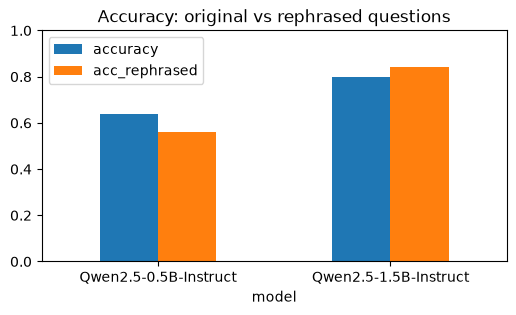

In [9]:
summary[["accuracy", "acc_rephrased"]].plot(kind="bar", ylim=(0, 1), rot=0, figsize=(6, 3))
plt.title("Accuracy: original vs rephrased questions")
plt.show()

The per-task results show where a model failed and what it answered:

In [10]:
results[MODELS[0]]["original"]

,task,correct,right_tools,model_calls,tool_calls,tokens,seconds,answer
0,1,True,True,2,1,36,6.8,The current temperature in Tokyo is 26.0 degre...
1,2,True,True,2,1,35,6.9,The current temperature in London is 14.0 degr...
2,3,True,True,2,1,35,6.7,The current temperature in Paris is 21.0 degre...
3,4,True,True,2,1,36,6.9,The current temperature in Rome is 29.0 degree...
4,5,True,True,2,1,35,6.7,The current temperature in Oslo is 8.0 degrees...
5,6,True,True,2,1,36,7.0,The current temperature in Dubai is 41.0 degre...
6,7,True,True,2,1,36,6.9,The current temperature in Sydney is 23.0 degr...
7,8,True,True,2,1,36,6.8,The current temperature in Bangkok is 33.0 deg...
8,9,False,False,1,0,35,4.1,To provide you with the current temperature in...
9,10,True,True,2,1,44,7.4,The total cost for 7 nights at the hotel would...


In [11]:
results[MODELS[1]]["original"]

,task,correct,right_tools,model_calls,tool_calls,tokens,seconds,answer
0,1,True,True,2,1,36,20.6,The current temperature in Tokyo is 26.0 degre...
1,2,True,True,2,1,35,20.3,The current temperature in London is 14.0 degr...
2,3,True,True,2,1,35,20.3,The current temperature in Paris is 21.0 degre...
3,4,True,True,2,1,36,20.7,The current temperature in Rome is 29.0 degree...
4,5,True,True,2,1,37,20.7,"Right now, the temperature in Oslo is 8.0 degr..."
5,6,True,True,2,1,36,20.6,The current temperature in Dubai is 41.0 degre...
6,7,True,True,2,1,36,20.5,The current temperature in Sydney is 23.0 degr...
7,8,True,True,2,1,36,20.1,The current temperature in Bangkok is 33.0 deg...
8,9,True,True,2,1,40,21.3,The current temperature in Reykjavik is 3.0 de...
9,10,True,True,2,1,51,22.8,The cost for 7 nights at a hotel that costs 12...


## 7. Findings

- The 1.5B model is clearly more accurate (0.80 vs 0.64). But it failed 4 of the 8 two-tool questions by not calling any tool at all. For the Cairo question it even claimed it has no access to weather data.
- The 0.5B model is solid with a single tool call (8 of 9 weather questions, 6 of 8 calculator questions) but breaks on chains: on the Fahrenheit questions it returned the Celsius value and stopped. Twice it sent a broken expression to the calculator and answered from the error text.
- Right answers without the right tools happen on both sides. The 0.5B model solved two temperature comparisons with mental math after two weather calls. The 1.5B model computed 85 * 14 in its head without the calculator. That is why the tool scores differ from the accuracies.
- Rephrasing hurt the small model (0.64 to 0.56) but helped the big one (0.80 to 0.84). The casual wording seems to unlock its tool use.
- With our first 6 tasks the ranking was reversed, there the small model looked better (0.83 vs 0.67). One answer moved accuracy by 0.17 back then, now only by 0.04. The bigger task set changed our conclusion.
- So there is more to agents than accuracy: tool use, robustness and cost show what the accuracy number hides.